In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


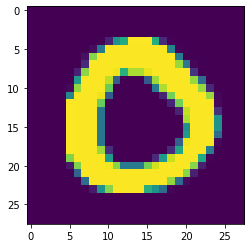

In [3]:
import matplotlib.pyplot as plt

plt.imshow(data.iloc[4,1:].to_numpy().reshape(28,28))

In [4]:
data.iloc[50,1:].to_numpy().reshape(1,784)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0

In [5]:
x = data.drop(columns=['label'])
y = data.label

In [6]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [7]:
import tensorflow as tf
%load_ext tensorboard

In [8]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(4,activation='sigmoid',input_shape=(784,)))
model.add(Dense(5,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4)                 3140      
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 25        
_________________________________________________________________
dense_2 (Dense)              (None, 3)                 18        
Total params: 3,183
Trainable params: 3,183
Non-trainable params: 0
_________________________________________________________________


2022-09-28 06:16:57.530443: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [9]:
from tensorflow import keras
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


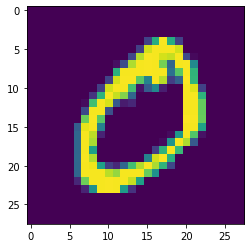

In [10]:
plt.imshow(x_train[1])

In [11]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense,Flatten
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(4,activation='sigmoid'))
model.add(Dense(5,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 3140      
_________________________________________________________________
dense_4 (Dense)              (None, 5)                 25        
_________________________________________________________________
dense_5 (Dense)              (None, 10)                60        
Total params: 3,225
Trainable params: 3,225
Non-trainable params: 0
_________________________________________________________________


In [12]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = 'adam',metrics=['accuracy'])

In [13]:
model.fit(x_train,y_train,epochs=50)

2022-09-28 06:16:58.694413: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/50
1875/1875 [==============================] - 5s 2ms/step - loss: 1.7034 - accuracy: 0.3668
Epoch 2/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.3732 - accuracy: 0.4467
Epoch 3/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2850 - accuracy: 0.4972
Epoch 4/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2356 - accuracy: 0.5212
Epoch 5/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2250 - accuracy: 0.5252
Epoch 6/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2064 - accuracy: 0.5321
Epoch 7/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.1832 - accuracy: 0.5426
Epoch 8/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2059 - accuracy: 0.5347
Epoch 9/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.1765 - accuracy: 0.5444
Epoch 10/50
1875/1875 [==============================] - 4s 2ms/step - loss: 1.176

In [14]:
pred=model.predict(x_train)
pred

array([[4.02643561e-01, 4.78275776e-01, 1.81018170e-02, ...,
        5.79950726e-03, 3.72128263e-02, 9.90218250e-04],
       [4.02643561e-01, 4.78275776e-01, 1.81018170e-02, ...,
        5.79950726e-03, 3.72128263e-02, 9.90218250e-04],
       [1.13635499e-04, 7.53493223e-05, 2.14882214e-02, ...,
        8.81240051e-03, 5.47767477e-03, 1.46420673e-01],
       ...,
       [1.54633615e-02, 3.10578886e-02, 3.69548686e-02, ...,
        9.56029457e-04, 2.88359344e-01, 8.38192645e-03],
       [5.10886498e-02, 1.77718811e-02, 9.33731645e-02, ...,
        1.73256427e-04, 8.52964353e-03, 1.96169160e-04],
       [1.54633615e-02, 3.10578886e-02, 3.69548686e-02, ...,
        9.56029457e-04, 2.88359344e-01, 8.38192645e-03]], dtype=float32)

In [15]:
pred.argmax(axis=1)

array([1, 1, 4, ..., 3, 6, 3])

In [16]:
model.predict(x_test[1].reshape(1,28,28)).argmax(axis=1)

array([2])

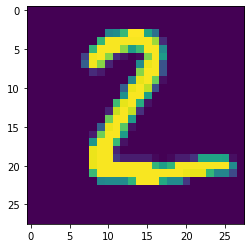

In [17]:
plt.imshow(x_test[1])